# ResNet18 Fine-tuning for Rice Disease Classification

Phân loại 4 loại bệnh trên lá lúa sử dụng ResNet18 pre-trained

## Bước 1: Import Libraries


In [2]:
!pip -q install gdown

# Tải file trực tiếp bằng ID và đặt tên file đầu ra là archive.zip
!gdown --fuzzy "https://drive.google.com/file/d/1Ff5jJQXtHIKnjKcZ-M4LR2ZUILxDIFBB/view?usp=sharing" -O data_tonghop_tk1.zip

!unzip -o -q /kaggle/working/data_tonghop_tk1.zip

Downloading...
From (original): https://drive.google.com/uc?id=1Ff5jJQXtHIKnjKcZ-M4LR2ZUILxDIFBB
From (redirected): https://drive.google.com/uc?id=1Ff5jJQXtHIKnjKcZ-M4LR2ZUILxDIFBB&confirm=t&uuid=ac07eb3d-c218-4010-ba8f-183ed9baebbd
To: /kaggle/working/data_tonghop_tk1.zip
100%|███████████████████████████████████████| 4.98G/4.98G [00:36<00:00, 135MB/s]


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import os
import cv2
import numpy as np
import time
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


## Bước 2: Configuration


In [9]:
DATA_PATH = "/kaggle/working/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_tonghop_tk1"
IMAGE_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 15
PATIENCE = 3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")


Device: cuda
CUDA available: True


## Bước 3: Data Preprocessing Functions


In [10]:
def brighten_image(img, factor=1.2):
    brightened = cv2.convertScaleAbs(img, alpha=factor, beta=0)
    return brightened

def enhance_contrast(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return enhanced

def sharpen_image(img, strength=0.5):
    kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
    sharpened = cv2.filter2D(img, -1, kernel)
    result = cv2.addWeighted(img, 1 - strength, sharpened, strength, 0)
    return result

def process_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)
    if img is None:
        return None

    img = brighten_image(img)
    img = enhance_contrast(img)
    img = sharpen_image(img)
    img = cv2.resize(img, target_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def split_dataset_stratified(data_dir, test_size=0.2, val_size=0.1, random_state=42):
    file_paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))

    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    file_paths.append(os.path.join(class_dir, file_name))
                    labels.append(class_idx)

    X_temp, X_test, y_temp, y_test = train_test_split(
        file_paths, labels, test_size=test_size,
        random_state=random_state, stratify=labels
    )

    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted,
        random_state=random_state, stratify=y_temp
    )

    return (X_train, X_val, X_test), (y_train, y_val, y_test), class_names


## Bước 4: Load and Split Dataset


Classes: ['Đốm nâu (Brow Spot)', 'Đạo ôn (Leaf Blast)', 'Cháy lá (Leaf Blight)', 'Bình thường (Normal)']
Number of classes: 4
Train samples: 8279
Validation samples: 1183
Test samples: 2366


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


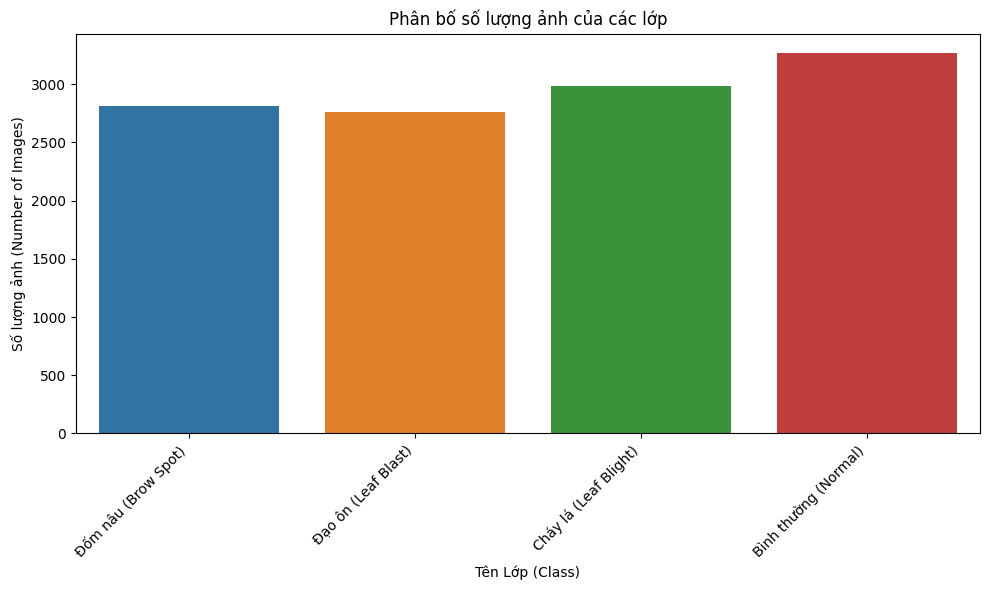

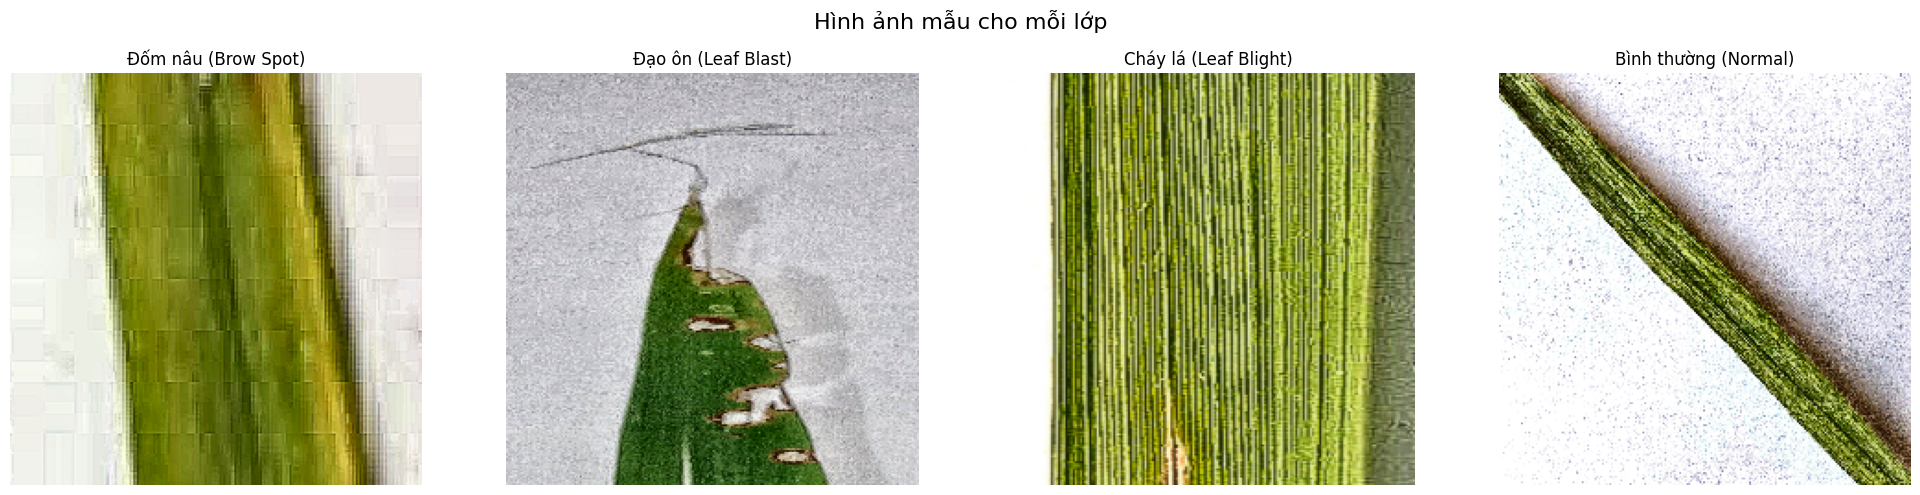

In [11]:
(X_train, X_val, X_test), (y_train, y_val, y_test), original_class_names = split_dataset_stratified(DATA_PATH)

class_name_mapping = {
    '01': 'Đốm nâu (Brow Spot)',
    '02': 'Đạo ôn (Leaf Blast)',
    '03': 'Cháy lá (Leaf Blight)',
    '04': 'Bình thường (Normal)'
}
class_names = [class_name_mapping.get(name, name) for name in sorted(original_class_names)]
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

from collections import Counter

all_labels_pretty = []
for original_name in sorted(original_class_names):
    class_dir = os.path.join(DATA_PATH, original_name)
    if os.path.isdir(class_dir):
        num_files = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        all_labels_pretty.extend([class_name_mapping.get(original_name, original_name)] * num_files)
label_counts = Counter(all_labels_pretty)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.title('Phân bố số lượng ảnh của các lớp')
plt.xlabel('Tên Lớp (Class)')
plt.ylabel('Số lượng ảnh (Number of Images)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, num_classes, figsize=(20, 5))
fig.suptitle('Hình ảnh mẫu cho mỗi lớp', fontsize=16)
for i, original_name in enumerate(sorted(original_class_names)):
    class_dir = os.path.join(DATA_PATH, original_name)
    if os.path.isdir(class_dir) and len(os.listdir(class_dir)) > 0:
        sample_img_name = os.listdir(class_dir)[0]
        img = process_image(os.path.join(class_dir, sample_img_name))
        if img is not None:
            axes[i].imshow(img)
            axes[i].set_title(class_name_mapping.get(original_name, original_name))
            axes[i].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Bước 5: PyTorch Dataset Class


In [12]:
class RiceDiseaseDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        label = self.labels[idx]

        img = process_image(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        if img is None:
            img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)

        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, label


## Bước 6: Data Transforms and DataLoaders


In [17]:
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = RiceDiseaseDataset(X_train, y_train, transform=train_transform)
val_dataset = RiceDiseaseDataset(X_val, y_val, transform=val_test_transform)
test_dataset = RiceDiseaseDataset(X_test, y_test, transform=val_test_transform)


class_counts = np.bincount(y_train)
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
samples_weights = class_weights[y_train]

sampler = torch.utils.data.WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
)


dl_train = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4)


dl_val = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
dl_test = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


print(f"Train batches: {len(dl_train)}")
print(f"Validation batches: {len(dl_val)}")
print(f"Test batches: {len(dl_test)}")
print("\nĐã áp dụng WeightedRandomSampler để xử lý mất cân bằng dữ liệu trên tập train.")

Train batches: 130
Validation batches: 19
Test batches: 37

Đã áp dụng WeightedRandomSampler để xử lý mất cân bằng dữ liệu trên tập train.


## Bước 7: Model Setup


In [21]:
try:
    print("Loading ResNet18 with ImageNet weights...")
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

except Exception as e:
    print(f"Network error: {str(e)[:100]}...")

    model = models.resnet18(weights=None)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

best_val_acc = 0.0
save_path = "/kaggle/working//fine_tuning_1_best_model.pth"

print(f"\nModel loaded: ResNet18")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Loading ResNet18 with ImageNet weights...

Model loaded: ResNet18
Total parameters: 11,178,564
Trainable parameters: 11,178,564


## Bước 8: Training Function


In [23]:
def run_epoch(dataloader, train=True):
    model.train(mode=train)
    epoch_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return epoch_loss/total, correct/total


## Bước 9: Training Loop


In [24]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []

best_val_loss = float('inf')
patience_counter = 0

print("Bắt đầu quá trình huấn luyện...")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(dl_train, train=True)
    val_loss, val_acc = run_epoch(dl_val, train=False)
    scheduler.step()

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"time={time.time()-t0:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({"model": model.state_dict(),
                    "classes": class_names}, save_path)
        print(f"  -> Val loss cải thiện. Lưu model tốt nhất vào {save_path} (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  -> Val loss không cải thiện. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping được kích hoạt ở epoch {epoch}!")
        break

print(f"\nTraining hoàn tất. Model tốt nhất có Validation Accuracy: {best_val_acc:.4f}")


Bắt đầu quá trình huấn luyện...
[01/15] train_loss=0.4978 acc=0.8105 | val_loss=0.4259 acc=0.8411 | time=199.5s
  -> Val loss cải thiện. Lưu model tốt nhất vào /kaggle/working//fine_tuning_1_best_model.pth (val_loss=0.4259)
[02/15] train_loss=0.3155 acc=0.8808 | val_loss=0.3939 acc=0.8394 | time=188.8s
  -> Val loss cải thiện. Lưu model tốt nhất vào /kaggle/working//fine_tuning_1_best_model.pth (val_loss=0.3939)
[03/15] train_loss=0.2612 acc=0.8994 | val_loss=0.3194 acc=0.8791 | time=188.2s
  -> Val loss cải thiện. Lưu model tốt nhất vào /kaggle/working//fine_tuning_1_best_model.pth (val_loss=0.3194)
[04/15] train_loss=0.2264 acc=0.9127 | val_loss=0.3254 acc=0.8698 | time=186.7s
  -> Val loss không cải thiện. Patience: 1/3
[05/15] train_loss=0.1662 acc=0.9361 | val_loss=0.2467 acc=0.9028 | time=189.4s
  -> Val loss cải thiện. Lưu model tốt nhất vào /kaggle/working//fine_tuning_1_best_model.pth (val_loss=0.2467)
[06/15] train_loss=0.1534 acc=0.9378 | val_loss=0.2175 acc=0.9121 | time=19

## Bước 10: Evaluation on Test Set


In [27]:
checkpoint = torch.load(save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model'])

model.eval()
test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in dl_test:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        preds = logits.argmax(1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Test Accuracy: 0.9400 (94.00%)

Classification Report:
                       precision    recall  f1-score   support

  Đốm nâu (Brow Spot)       0.98      0.95      0.96       562
  Đạo ôn (Leaf Blast)       0.86      0.93      0.90       552
Cháy lá (Leaf Blight)       0.94      0.90      0.92       598
 Bình thường (Normal)       0.98      0.97      0.97       654

             accuracy                           0.94      2366
            macro avg       0.94      0.94      0.94      2366
         weighted avg       0.94      0.94      0.94      2366



## Bước 11: Visualization


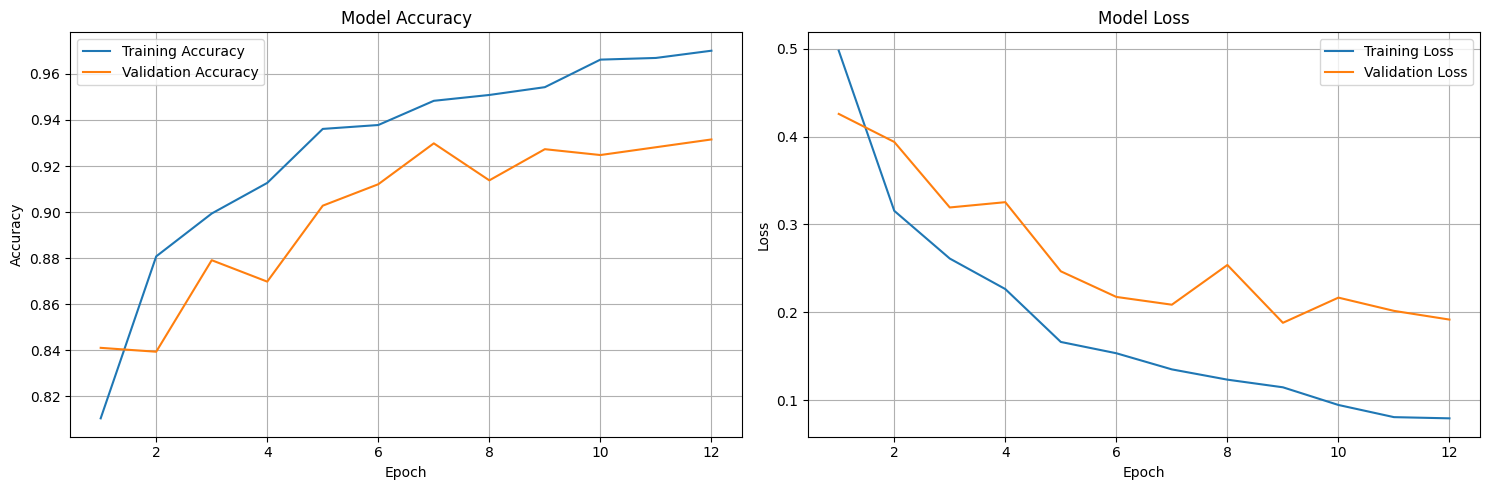

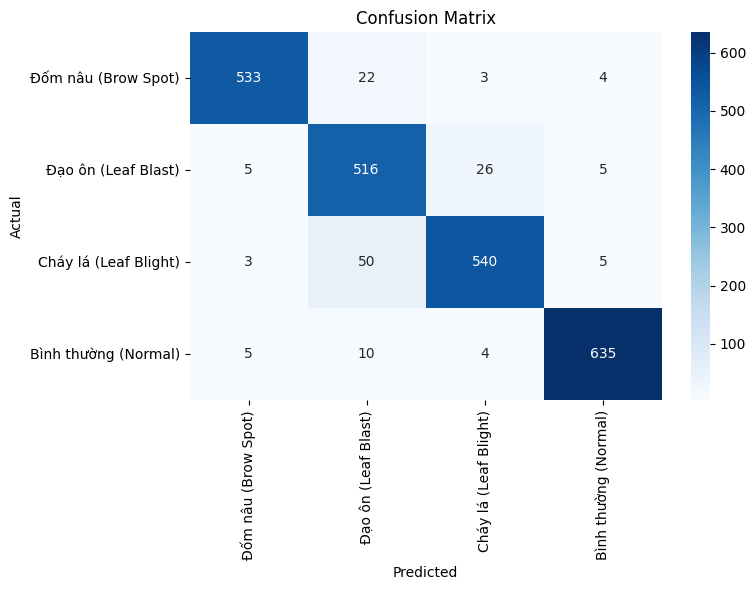

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(train_accs) + 1)

ax1.plot(epochs_range, train_accs, label='Training Accuracy')
ax1.plot(epochs_range, val_accs, label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, train_losses, label='Training Loss')
ax2.plot(epochs_range, val_losses, label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## Bước 12: Đo lường tốc độ dự đoán FPS



Kết quả đo tốc độ dự đoán
Số lần đo: 100
Thời gian dự đoán trung bình: 2.80 ms
Độ lệch chuẩn: 0.10 ms
Tốc độ dự đoán (FPS): 357.45 frames/second

Tốc độ dự đoán theo batch size:
------------------------------------------------------------
Batch size  1:  352.69 images/second
Batch size  8:  903.51 images/second
Batch size 16: 1215.61 images/second
Batch size 32: 1328.40 images/second
Batch size 64: 1312.29 images/second


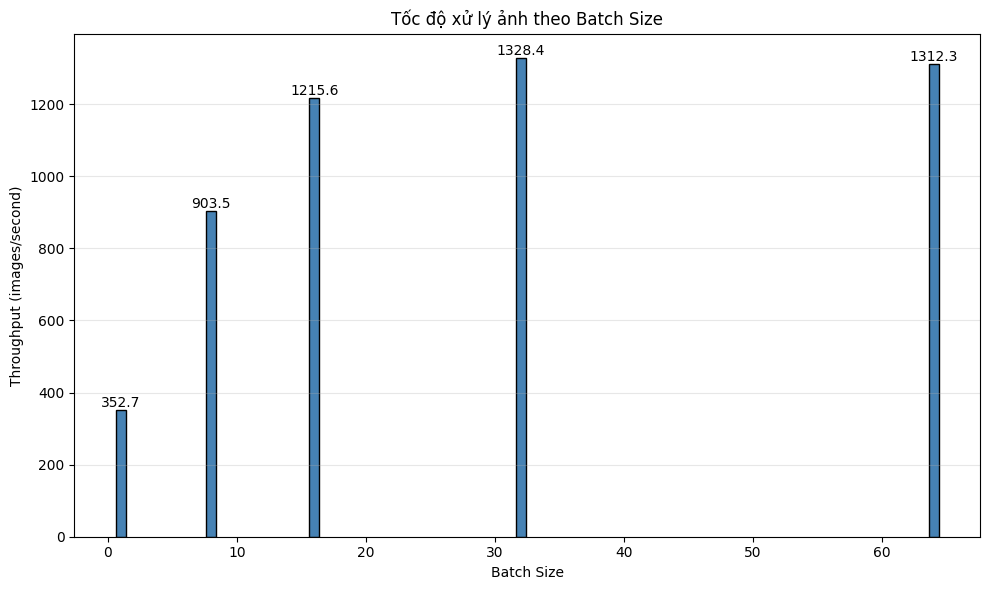

In [29]:
model.eval()

num_warmup = 10
num_iterations = 100

with torch.no_grad():
    dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    for _ in range(num_warmup):
        _ = model(dummy_input)

if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_times = []

with torch.no_grad():
    for _ in range(num_iterations):
        dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
        
        start_time = time.time()
        _ = model(dummy_input)
        
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        
        end_time = time.time()
        inference_times.append(end_time - start_time)

avg_inference_time = np.mean(inference_times)
std_inference_time = np.std(inference_times)
fps = 1.0 / avg_inference_time

print("\n" + "="*60)
print("Kết quả đo tốc độ dự đoán")
print("="*60)
print(f"Số lần đo: {num_iterations}")
print(f"Thời gian dự đoán trung bình: {avg_inference_time*1000:.2f} ms")
print(f"Độ lệch chuẩn: {std_inference_time*1000:.2f} ms")
print(f"Tốc độ dự đoán (FPS): {fps:.2f} frames/second")
print("="*60)

batch_sizes = [1, 8, 16, 32, 64]
batch_fps_results = {}

for bs in batch_sizes:
    with torch.no_grad():
        dummy_batch = torch.randn(bs, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
        for _ in range(num_warmup):
            _ = model(dummy_batch)
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    batch_times = []
    with torch.no_grad():
        for _ in range(num_iterations):
            dummy_batch = torch.randn(bs, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
            
            start_time = time.time()
            _ = model(dummy_batch)
            
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            end_time = time.time()
            batch_times.append(end_time - start_time)
    
    avg_batch_time = np.mean(batch_times)
    batch_fps = bs / avg_batch_time
    batch_fps_results[bs] = batch_fps

print("\nTốc độ dự đoán theo batch size:")
print("-" * 60)
for bs, fps_val in batch_fps_results.items():
    print(f"Batch size {bs:2d}: {fps_val:7.2f} images/second")
print("="*60)

plt.figure(figsize=(10, 6))
plt.bar(batch_fps_results.keys(), batch_fps_results.values(), color='steelblue', edgecolor='black')
plt.xlabel('Batch Size')
plt.ylabel('Throughput (images/second)')
plt.title('Tốc độ xử lý ảnh theo Batch Size')
plt.grid(axis='y', alpha=0.3)
for bs, fps_val in batch_fps_results.items():
    plt.text(bs, fps_val, f'{fps_val:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
